In [22]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN


shootings = "../data/Shootings_2006-Present_20260608_CLEANED.csv"
victims = "../data/Shooting_Victims_2006-Present_20260608.csv"
#weather = "../data/ncei_noaa_weather_JFK_international_airport_CLEANED.csv"
df_victims = pd.read_csv(victims)
df_shootings = pd.read_csv(shootings)
df_shootings.head(3)

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night
0,212200405,04/20/2020,19:36:00,BROOKLYN,OUTSIDE,79,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1000301.0,192923.0,40.696199,-73.942118,2020-04-20 19:36:00,Monday,Day
1,139554478,11/07/2014,03:20:00,BRONX,INSIDE,42,0.0,DWELLING,PVT HOUSE,1012185.0,241494.0,40.829485,-73.899059,2014-11-07 03:20:00,Friday,Night
2,167619814,08/01/2017,00:35:00,BRONX,OUTSIDE,47,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1030360.0,261043.0,40.883065,-73.833250,2017-08-01 00:35:00,Tuesday,Night


In [23]:
#datetime is most likely a string (needs to be converted back to datetime
df_shootings.info()

<class 'pandas.DataFrame'>
RangeIndex: 24127 entries, 0 to 24126
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   INCIDENT_KEY        24127 non-null  int64  
 1   OCCUR_DATE          24127 non-null  str    
 2   OCCUR_TIME          24127 non-null  str    
 3   BORO                24127 non-null  str    
 4   LOC_OF_OCCUR_DESC   24127 non-null  str    
 5   PRECINCT            24127 non-null  int64  
 6   JURISDICTION_CODE   24125 non-null  float64
 7   LOC_CLASSFCTN_DESC  24094 non-null  str    
 8   LOCATION_DESC       9693 non-null   str    
 9   X_COORD_CD          24126 non-null  float64
 10  Y_COORD_CD          24126 non-null  float64
 11  Latitude            24126 non-null  float64
 12  Longitude           24126 non-null  float64
 13  datetime            24127 non-null  str    
 14  day_of_week         24127 non-null  str    
 15  day_or_night        24127 non-null  str    
dtypes: float64(5), 

In [24]:
#need to convert "datetime" into a datetime again 
df_shootings['datetime'] = pd.to_datetime(df_shootings['datetime'])


## Remove Unwanted Columns from df_shootings Dataset

In [25]:
#Already have a datetime column so will remove OCCUR_DATE	OCCUR_TIME
#X_COORD_CD	Y_COORD_CD may be useful for clustering analysis i.e. DBSCAN  - these datapoints provide an easy way to judge distances between shootings in feet 
df_shootings.drop(columns=['OCCUR_DATE', 'OCCUR_TIME'], inplace=True)
df_shootings.head()

,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night
0,212200405,BROOKLYN,OUTSIDE,79,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1000301.0,192923.0,40.696199,-73.942118,2020-04-20 19:36:00,Monday,Day
1,139554478,BRONX,INSIDE,42,0.0,DWELLING,PVT HOUSE,1012185.0,241494.0,40.829485,-73.899059,2014-11-07 03:20:00,Friday,Night
2,167619814,BRONX,OUTSIDE,47,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1030360.0,261043.0,40.883065,-73.833250,2017-08-01 00:35:00,Tuesday,Night
3,212516311,BRONX,OUTSIDE,46,0.0,STREET,NaN,1009085.0,248078.0,40.847565,-73.910236,2020-04-29 15:30:00,Wednesday,Day
4,270150948,QUEENS,OUTSIDE,108,0.0,STREET,NaN,1004925.0,209948.0,40.742919,-73.925390,2023-06-20 23:41:00,Tuesday,Night


## Did a shooting result in at least one murder?
### Merging "STAT_MURDER_FLG" from df_victims into df_shootings


In [26]:
#Just a quick peak at df_victims dataset to see what we can use this for!
df_victims.head(3)

,INCIDENT_KEY,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG
0,299453927,299453927-1,25-44,MALE,BLACK,N
1,212336415,212336415-1,18-24,MALE,BLACK,N
2,280768895,280768895-1,25-44,MALE,BLACK,N


 - There are (or can be) multiple victims per shooting occurance so all we can assess here is whether a shooting resulted in **at least one murder (manslaughter)** 

In [27]:
# Let's also see if there are any shooting incidents where no victims were recorded
# i.e. incident key exists in df_shootings but does not exist in df_victims.
missing = set(df_shootings['INCIDENT_KEY']) - set(df_victims['INCIDENT_KEY'])
len(missing)

0

In [28]:
missing

set()

- Okay, so all shootings in df_shootings have at least one recorded victim

In [29]:
#Let's see if any incident keys that exist in df_victims but have no matching shooting record. 
#if so, we have "orphaned" victim rows - they reference an incident that, according to df_shootings, doesn't exist.
orphaned_keys = set(df_victims['INCIDENT_KEY']) - set(df_shootings['INCIDENT_KEY'])
df_victims[df_victims['INCIDENT_KEY'].isin(orphaned_keys)]

,INCIDENT_KEY,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG
11568,78019135,78019135-20239,25-44,MALE,BLACK HISPANIC,N
28911,203259656,NaN,NaN,NaN,NaN,NaN


- For some reason these shooting incidents {78019135, 203259656} have been removed or not properly recorded in the df_shootings dataset.
- For my purposes, I will exclude VICTIM_ID: 78019135-20239 because I cannot attach it to a date or a location
- I want to explore the increase in shootings and killings in each 5 boroughs pre, during and post COVID-19 pandemic (this also coincided with George Floyd murder 25-May-2020 and resulting social unrest). I want to keep my focus on analyzing where rapid decline in shootings took place.

In [30]:
#Removing the "orphaned" rows but keeping original df_victims dataframe untouched
df_victims_clean = df_victims[~df_victims['INCIDENT_KEY'].isin(orphaned_keys)]

In [31]:
#Because we can have multiple victims per shooting incident, we need to groupby('INCIDENT_KEY')

#create True or False values to make aggregation easier
df_victims_clean['is_death'] = df_victims_clean['STAT_MURDER_FLG'] == 'Y'

incident_summary = df_victims_clean.groupby('INCIDENT_KEY').agg(
    n_victims = ('VICTIM_ID', 'count'),
    n_deaths  = ('is_death', 'sum')
).reset_index()

incident_summary.head(5)
    

,INCIDENT_KEY,n_victims,n_deaths
0,9953245,1,0
1,9953246,1,0
2,9953247,3,0
3,9953248,1,0
4,9953249,1,1


In [32]:
df_victims_clean.nsmallest(7, 'INCIDENT_KEY')

,INCIDENT_KEY,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG,is_death
7985,9953245,9953245-8156,<18,MALE,BLACK,N,False
1507,9953246,9953246-8158,18-24,MALE,WHITE HISPANIC,N,False
5490,9953247,9953247-8160,18-24,MALE,BLACK,N,False
5491,9953247,9953247-8161,18-24,MALE,BLACK,N,False
5492,9953247,9953247-8162,18-24,MALE,BLACK,N,False
13,9953248,9953248-8163,18-24,MALE,BLACK,N,False
8476,9953249,9953249-8164,25-44,MALE,BLACK,Y,True


In [33]:
#also,INCIDENT_KEY should now be unique
incident_summary['INCIDENT_KEY'].duplicated().sum()

np.int64(0)

In [34]:
#Now, I can merge incident summary with df_shootings
df_shootings = df_shootings.merge(incident_summary, on='INCIDENT_KEY', how='left')
df_shootings.head()


,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,n_victims,n_deaths
0,212200405,BROOKLYN,OUTSIDE,79,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1000301.0,192923.0,40.696199,-73.942118,2020-04-20 19:36:00,Monday,Day,1,1
1,139554478,BRONX,INSIDE,42,0.0,DWELLING,PVT HOUSE,1012185.0,241494.0,40.829485,-73.899059,2014-11-07 03:20:00,Friday,Night,1,0
2,167619814,BRONX,OUTSIDE,47,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1030360.0,261043.0,40.883065,-73.833250,2017-08-01 00:35:00,Tuesday,Night,1,0
3,212516311,BRONX,OUTSIDE,46,0.0,STREET,NaN,1009085.0,248078.0,40.847565,-73.910236,2020-04-29 15:30:00,Wednesday,Day,1,0
4,270150948,QUEENS,OUTSIDE,108,0.0,STREET,NaN,1004925.0,209948.0,40.742919,-73.925390,2023-06-20 23:41:00,Tuesday,Night,1,0


In [39]:
#What's the max number of deaths in one shooting?
df_shootings.nlargest(10, 'n_deaths')

,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,n_victims,n_deaths
17612,203676928,BROOKLYN,INSIDE,77,0.0,COMMERCIAL,BAR/NIGHT CLUB,1003550.0,185644.0,40.676214,-73.930422,2019-10-12 06:55:00,Saturday,Day,7,4
22991,310357834,MANHATTAN,INSIDE,18,0.0,COMMERCIAL,NaN,991647.0,215481.0,40.758127,-73.973301,2025-07-28 18:28:00,Monday,Day,5,4
1054,29479155,BROOKLYN,OUTSIDE,73,0.0,STREET,NaN,1008421.0,178716.0,40.657186,-73.912886,2007-06-06 23:57:00,Wednesday,Night,3,3
1215,28523999,QUEENS,INSIDE,105,0.0,DWELLING,PVT HOUSE,1057644.0,192456.0,40.694628,-73.735330,2007-04-18 11:40:00,Wednesday,Day,3,3
1928,27415044,MANHATTAN,INSIDE,6,0.0,COMMERCIAL,NaN,984277.0,205026.0,40.729434,-73.999904,2007-03-14 21:26:00,Wednesday,Night,3,3
6765,71454843,QUEENS,INSIDE,105,0.0,DWELLING,PVT HOUSE,1053756.0,179914.0,40.660234,-73.749480,2010-02-22 06:58:00,Monday,Day,3,3
7961,85639528,QUEENS,OUTSIDE,113,0.0,VEHICLE,NaN,1051074.0,182502.0,40.667359,-73.759121,2012-07-07 05:03:00,Saturday,Day,3,3
8253,85152128,MANHATTAN,OUTSIDE,26,0.0,VEHICLE,NaN,994877.0,235128.0,40.812050,-73.961611,2012-06-07 18:20:00,Thursday,Day,3,3
10683,140697084,QUEENS,INSIDE,105,0.0,DWELLING,PVT HOUSE,1053348.0,178228.0,40.655610,-73.750968,2015-01-24 05:40:00,Saturday,Night,4,3
11617,146291688,BROOKLYN,OUTSIDE,88,0.0,HOUSING,MULTI DWELL - PUBLIC HOUS,989209.0,192197.0,40.694220,-73.982119,2015-09-20 01:40:00,Sunday,Night,3,3


In [38]:
#What's the max number of victims in one shooting?
df_shootings.nlargest(10, 'n_victims')

,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,n_victims,n_deaths
22994,311327863,BROOKLYN,OUTSIDE,71,0.0,COMMERCIAL,BAR/NIGHT CLUB,995600.0,182496.0,40.667587,-73.959088,2025-08-17 03:27:00,Sunday,Night,14,3
18494,200331333,BROOKLYN,OUTSIDE,73,0.0,PLAYGROUND,NaN,1011786.0,178738.0,40.657237,-73.900758,2019-07-27 22:53:00,Saturday,Night,12,1
9672,80484245,QUEENS,OUTSIDE,113,0.0,DWELLING,PVT HOUSE,1040363.0,188626.0,40.684242,-73.797680,2011-08-27 00:40:00,Saturday,Night,11,0
20796,243566417,BROOKLYN,INSIDE,72,1.0,TRANSIT,NaN,983024.0,177659.0,40.654318,-74.004420,2022-04-12 08:26:00,Tuesday,Day,10,0
23311,231637053,QUEENS,OUTSIDE,115,0.0,STREET,NaN,1020765.0,213373.0,40.752269,-73.868208,2021-07-31 22:36:00,Saturday,Night,10,0
23575,298756519,QUEENS,OUTSIDE,103,0.0,COMMERCIAL,BAR/NIGHT CLUB,1036944.0,194475.0,40.700317,-73.809962,2025-01-01 23:18:00,Wednesday,Night,10,0
12916,91399595,BROOKLYN,OUTSIDE,67,0.0,STREET,NaN,1004297.0,174456.0,40.645504,-73.927762,2013-06-30 00:51:00,Sunday,Night,9,0
13306,144995934,BROOKLYN,OUTSIDE,75,0.0,STREET,NaN,1020874.0,181725.0,40.665402,-73.867987,2015-08-02 02:16:00,Sunday,Night,9,0
19577,246884942,MANHATTAN,OUTSIDE,25,0.0,PLAYGROUND,NaN,1000558.0,231080.0,40.800930,-73.941098,2022-06-20 00:36:00,Monday,Night,9,1
8137,80584530,BRONX,OUTSIDE,47,0.0,DWELLING,PVT HOUSE,1022004.0,261897.0,40.885448,-73.863464,2011-09-04 03:33:00,Sunday,Night,8,0


In [16]:
#What data is missing?
df_victims[df_victims.isna().any(axis=1)]

,INCIDENT_KEY,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG
28911,203259656,NaN,NaN,NaN,NaN,NaN


In [33]:
#Cross reference with df_shootings dataframe
df_shootings[df_shootings["INCIDENT_KEY"] == 203259656]

,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night


- This Incident_key (203259656) is not found in the shootings dataset. So will remove this row from victims dataset **df_victims**.

In [34]:
#Need to drop the single missing row from df_victims before we can merge with df_shootings
df_victims = df_victims.dropna()

In [2]:
#Did a shooting result in at least one murder?
'''
df_merged = df_shootings.merge(
    df_victims[["INCIDENT_KEY", "STAT_MURDER_FLG"]], on="INCIDENT_KEY", how="left"
)
df_merged
''';

In [36]:
#check for missing values in STAT_MURDER_FLG in df_merged
df_merged[df_merged['STAT_MURDER_FLG'].isna()]

,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,STAT_MURDER_FLG


In [40]:
# Number of rows of missing values in df_merged
df_merged.isna().sum()

INCIDENT_KEY           0
BORO                   0
LOC_OF_OCCUR_DESC      0
PRECINCT               0
JURISDICTION_CODE      2
LOC_CLASSFCTN_DESC    35
X_COORD_CD             1
Y_COORD_CD             1
Latitude               1
Longitude              1
datetime               0
day_of_week            0
day_or_night           0
STAT_MURDER_FLG        0
dtype: int64

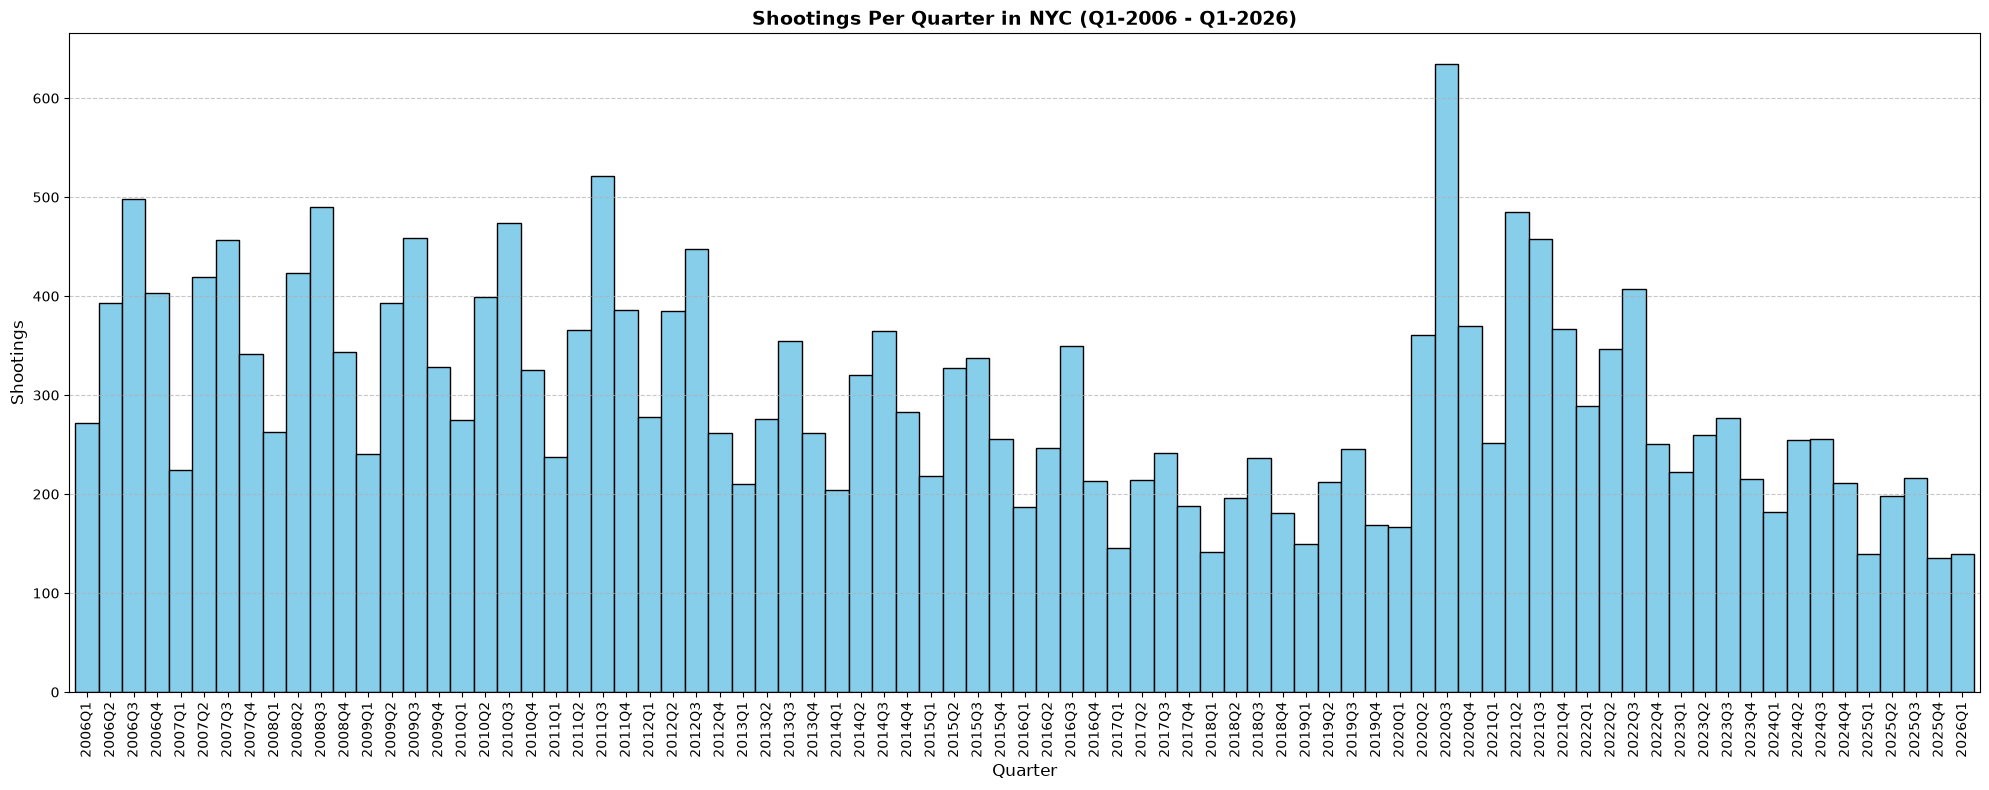

In [14]:
#breakdown of shooting occurences per quarter
shootings_per_quarter = df_shootings['datetime'].dt.to_period('Q').value_counts().sort_index()
plt.figure(figsize=(20, 8))
shootings_per_quarter.plot(kind='bar', width=1.0, color='skyblue', edgecolor='black')

plt.title('Shootings Per Quarter in NYC (Q1-2006 - Q1-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Shootings', fontsize=12)
#plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

- Shootings spiked during pandemic - **Not necessarily the lockdown itself but the ensuing chaos and uncertainty**
- In every single year (except 2021), Q3 has the highest rate of shootings
- Shootings remained consistent from 2006 to 2012 then gradually decreased from 2013 until Q3 2020 where they spiked higher than any time in the last 20 years
- Shootings have fallen, year by year and at a faster rate, since 2021
- Possible things to look into:
    - Elections
    - Pandemic
    - Who was governor in NYC
    - Work opportunities or lack or opportunities
- **Uncertainty**, **Instability**
- We are also assuming all shooting incidents are recorded (none are missed or unaccounted for)
- Even though shootings reduced in the late 20-teens, a shock (pandemic) undid whatever efforts were put in place to reduce this number 

- Academic paper titled: **Violence in the Big Apple throughout the COVID-19 pandemic: A borough-specific analysis** may shed light on spike in shootings from Q2 2020 See: https://pmc.ncbi.nlm.nih.gov/articles/PMC9095435/
- Citation: Wolff KT, Intravia J, Baglivio MT, Piquero AR. Violence in the Big Apple throughout the COVID-19 pandemic: A borough-specific analysis. J Crim Justice. 2022 Jul-Aug;81:101929. doi: 10.1016/j.jcrimjus.2022.101929. Epub 2022 May 12. PMID: 35578726; PMCID: PMC9095435. 

- New York Times: "In 2020, murders in the United States spiked more than 27 percent — the largest percentage increase in at least six decades." https://www.nytimes.com/2022/01/18/briefing/crime-surge-homicides-us.html 

## Break down of shootings by month

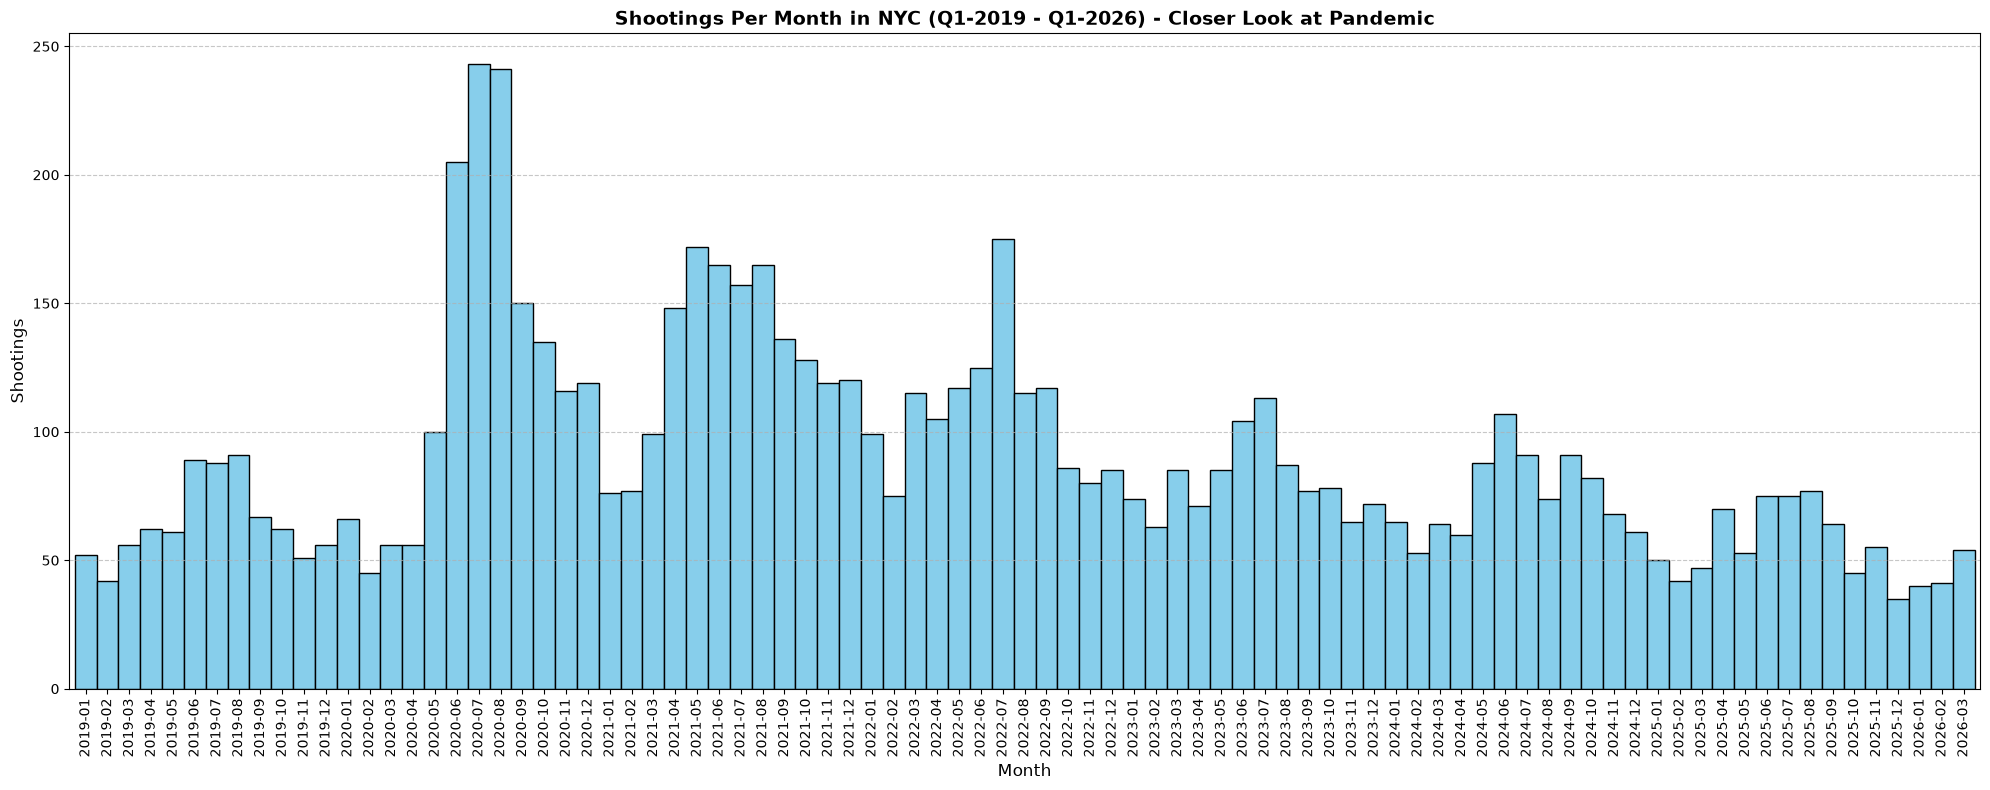

In [15]:
#Break down of shootings by month
mask = df_shootings['datetime'].between('2019-01-01', '2026-03-31')
shootings_per_month = df_shootings.loc[mask, 'datetime'].dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(20, 8))
shootings_per_month.plot(kind='bar', width=1.0, color='skyblue', edgecolor='black')

plt.title('Shootings Per Month in NYC (Q1-2019 - Q1-2026) - Closer Look at Pandemic', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Shootings', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

## Shootings and Deaths (Yearly Totals)

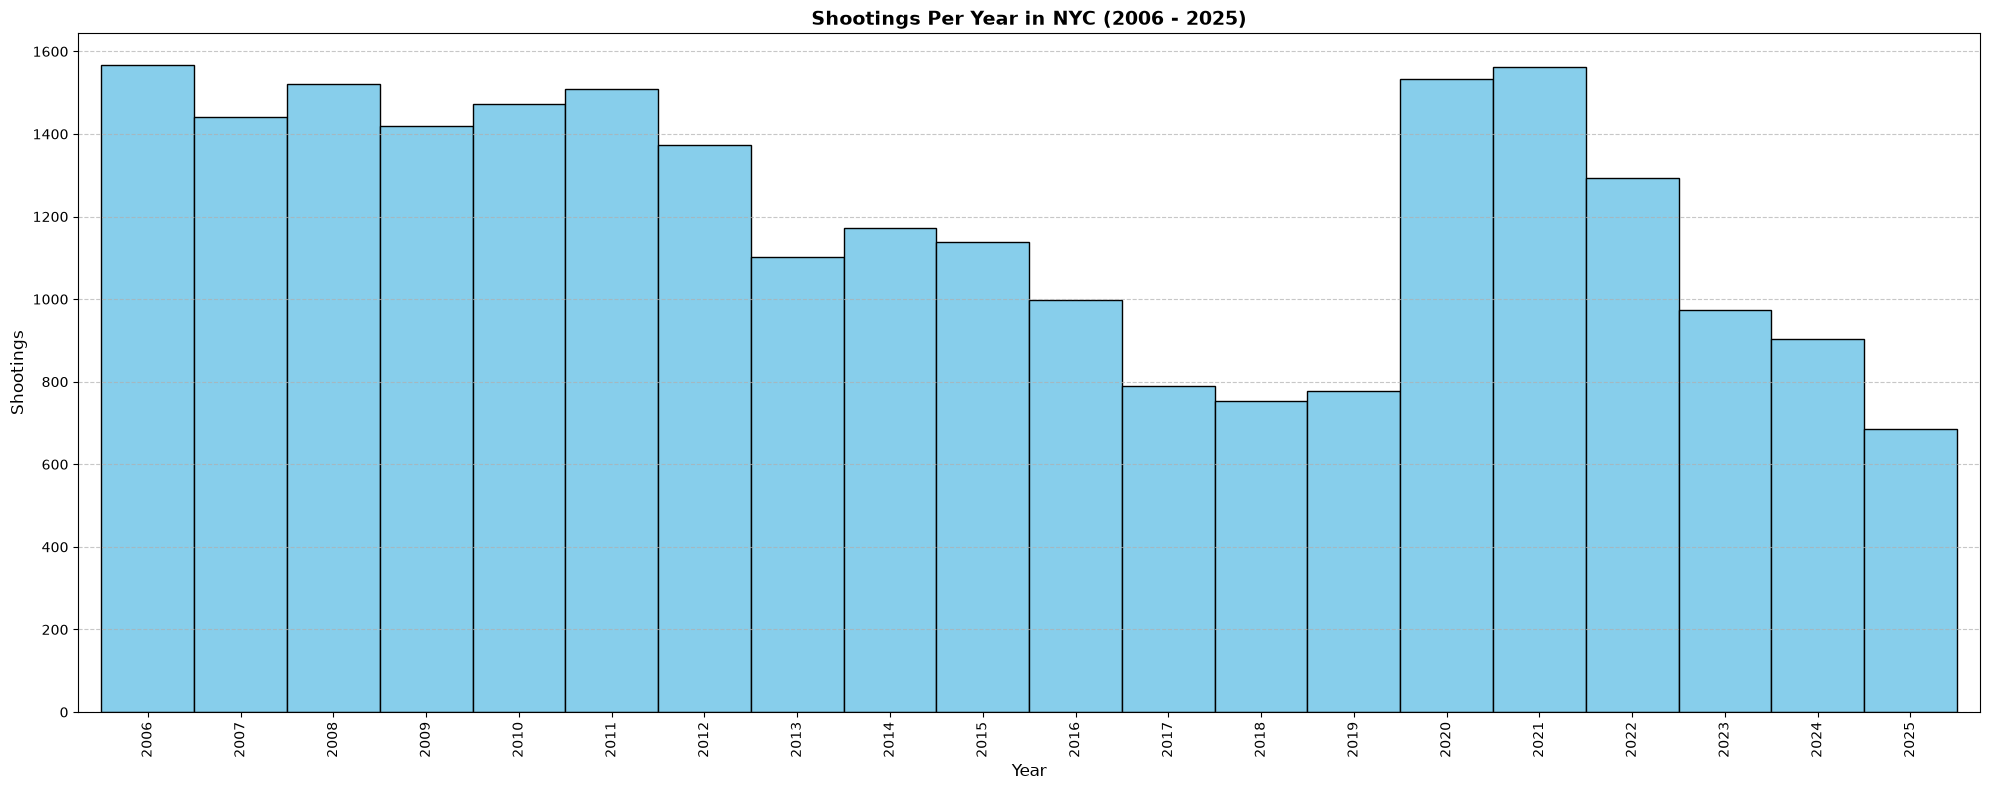

In [16]:
#Break down of shootings by Year From 2006 to and including 2025
mask = df_shootings['datetime'].between('2006-01-01', '2025-12-31')
shootings_per_year = df_shootings.loc[mask, 'datetime'].dt.to_period('Y').value_counts().sort_index()

plt.figure(figsize=(20, 8))
shootings_per_year.plot(kind='bar', width=1.0, color='skyblue', edgecolor='black')

plt.title('Shootings Per Year in NYC (2006 - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Shootings', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

- Shootings totals appears stable prior to pandemic at just under 800 shootings city-wide per year from 2017 to 2019. 
- Shooting totals, city-wide per year, had spiked during 2020 (specifically Q3 after George Floyd's Murder) and didn't fall to pre-pandemic levels until 2025.
- According to Academic paper titled: **Violence in the Big Apple throughout the COVID-19 pandemic: A borough-specific analysis** (https://pmc.ncbi.nlm.nih.gov/articles/PMC9095435/), increases in shootings were positively associated with the aftermath of the murder of George Floyd on 25th May 2020. But there was a “universal” (a negative association) across boroughs of shootings with an increase of both daily COVID-19 case counts and the NYS Pause stay-at-home order (the “shelter-in-place” order started on 22nd Mar 2020 and lasted just over 11 weeks until 8th Jun 2020)
- Also, the unrest following George Floyd’s murder resulted in a sizeable decline in shootings in Staten Island, But all other boroughs saw an increased shootings.
- While the effects of the initial NYC Pause were near universal across boroughs (decreased shootings), the unrest following George Floyd’s murder was associated with increased shootings across four of the five boroughs, while Staten Island had a sizeable decline.
- The academic paper: **Violence in the Big Apple throughout the COVID-19 pandemic: A borough-specific analysis** only had data up to 30th Sep 2021 - The data here extends to 31st Mar 2026 so we can see the aftermath of pandemic and George Floyd's murder


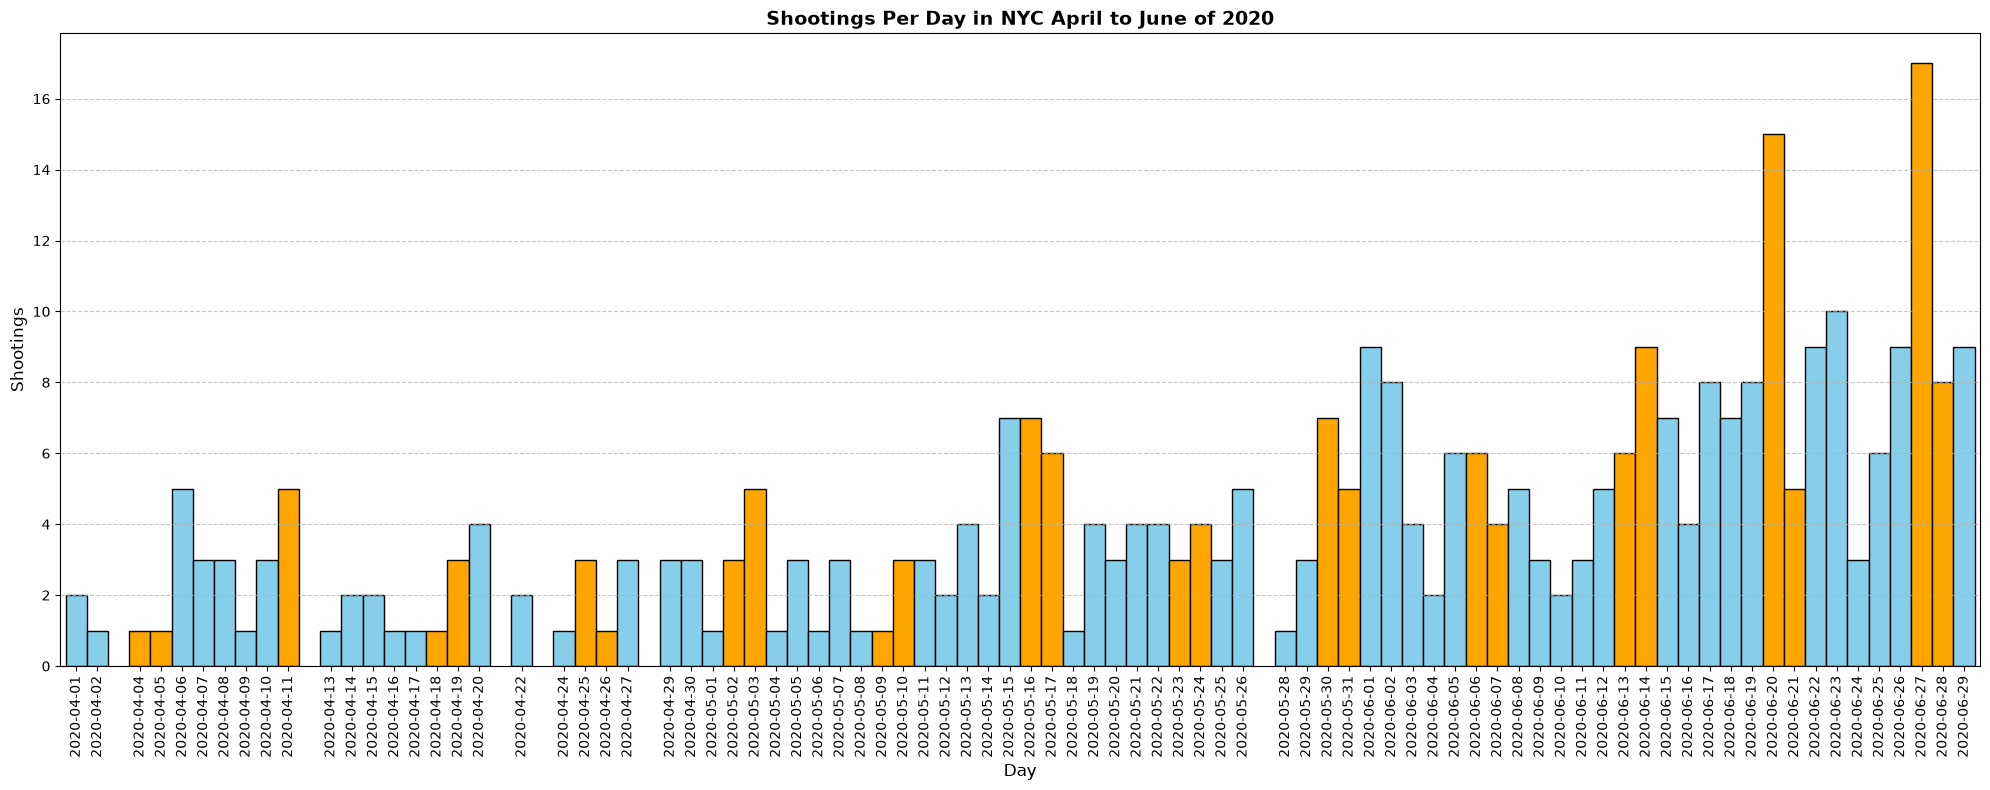

In [17]:
#Let's have a closer look at April to June of 2020 to see if shootings spiked after George Floyd's murder (25-May-2020)
mask = df_shootings['datetime'].between('2020-04-01', '2020-06-30')
shootings_per_day = df_shootings.loc[mask, 'datetime'].dt.to_period('D').value_counts().sort_index()

#colour weekends orange
bar_colors = ['orange' if d >= 5 else 'skyblue' for d in shootings_per_day.index.dayofweek]

plt.figure(figsize=(20, 8))
shootings_per_day.plot(kind='bar', width=1.0, color=bar_colors, edgecolor='black')

plt.title('Shootings Per Day in NYC April to June of 2020', fontsize=14, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Shootings', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

## Shootings during daylight and night-time hours
- Used the astral3.2 https://pypi.org/project/astral/ 
- **Day** means it's light enough to see without artificial light. **Night** means artificial light is required to see. See: **1_DataCleaning.ipynb**


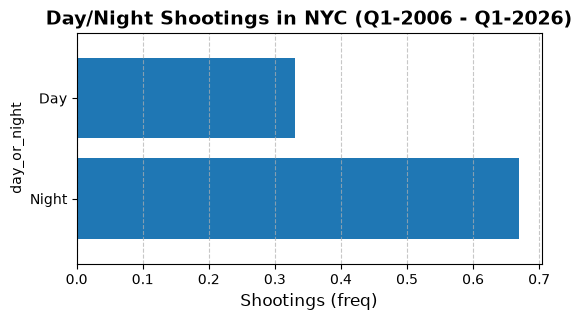

In [18]:
day_night_counts = df_shootings['day_or_night'].value_counts(normalize=True)
plt.figure(figsize=(6,3))
day_night_counts.plot(kind='barh', width=0.8)
plt.title('Day/Night Shootings in NYC (Q1-2006 - Q1-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Shootings (freq)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)


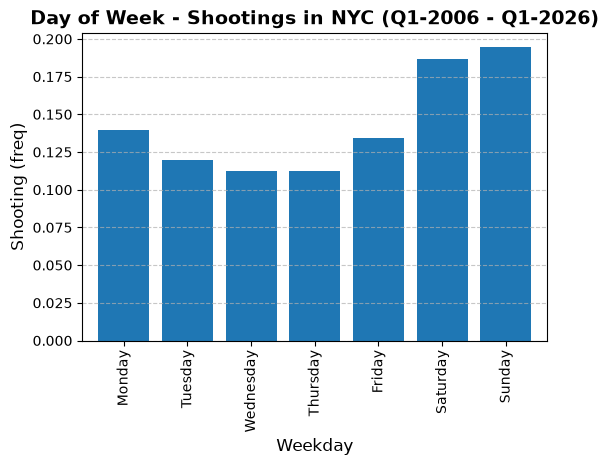

In [19]:
#Which day of week has more shootings?
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_of_week_counts = df_shootings["day_of_week"].value_counts(normalize=True).sort_index()
plt.figure(figsize=(6,4))
day_of_week_counts.reindex(day_order).plot(kind='bar', width=0.8)
plt.title('Day of Week - Shootings in NYC (Q1-2006 - Q1-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Weekday', fontsize=12)
plt.ylabel('Shooting (freq)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

## Shootings by Hour of Day

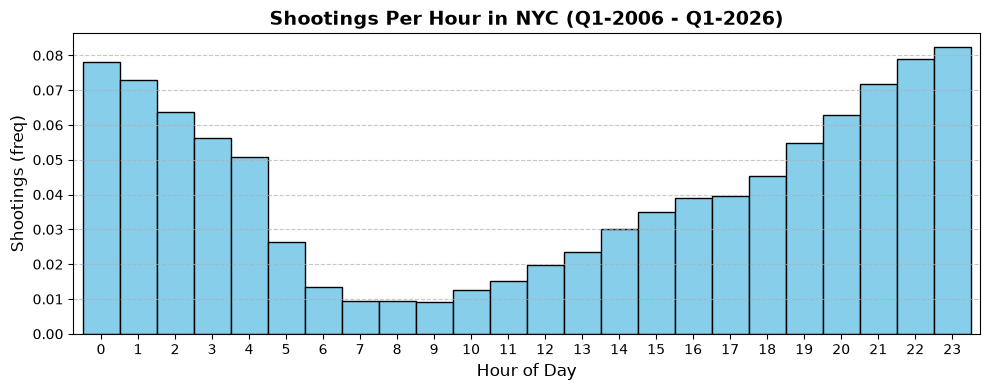

In [20]:

#Shootings by Hour of Day
shootings_per_Hour = df_shootings['datetime'].dt.hour.value_counts(normalize=True).sort_index()
plt.figure(figsize=(10,4))
shootings_per_Hour.plot(kind='bar', width=1.0, color='skyblue', edgecolor='black')

plt.title('Shootings Per Hour in NYC (Q1-2006 - Q1-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Shootings (freq)', fontsize=12)
plt.xticks(range(0, 24), rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

## EDA on Victims Dataset


In [21]:
df_victims.head()

,INCIDENT_KEY,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG
0,299453927,299453927-1,25-44,MALE,BLACK,N
1,212336415,212336415-1,18-24,MALE,BLACK,N
2,280768895,280768895-1,25-44,MALE,BLACK,N
3,141824677,141824677-27687,25-44,MALE,BLACK HISPANIC,N
4,270079203,270079203-1,45-64,MALE,BLACK,Y


In [22]:
victim_age = df_victims["VICTIM_AGE_GROUP"].value_counts(normalize=True)
display(victim_age)

VICTIM_AGE_GROUP
25-44      0.458441
18-24      0.360693
<18        0.103386
45-64      0.068244
65+        0.007229
UNKNOWN    0.001972
1022       0.000035
Name: proportion, dtype: float64

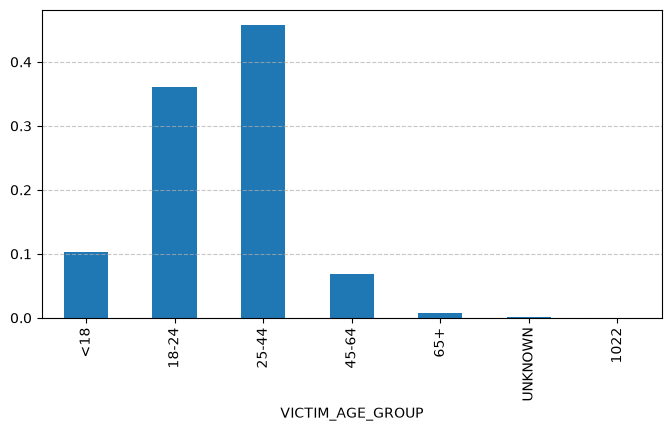

In [23]:
plt.figure(figsize=(8,4))
age_order = ['<18', '18-24', '25-44', '45-64', '65+', 'UNKNOWN', '1022']
victim_age.reindex(age_order).plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [24]:
victim_sex = df_victims["VICTIM_SEX"].value_counts(normalize=True)
display(victim_sex)

VICTIM_SEX
MALE        0.908582
FEMALE      0.091038
UNKNOWN     0.000346
INTERSEX    0.000035
Name: proportion, dtype: float64

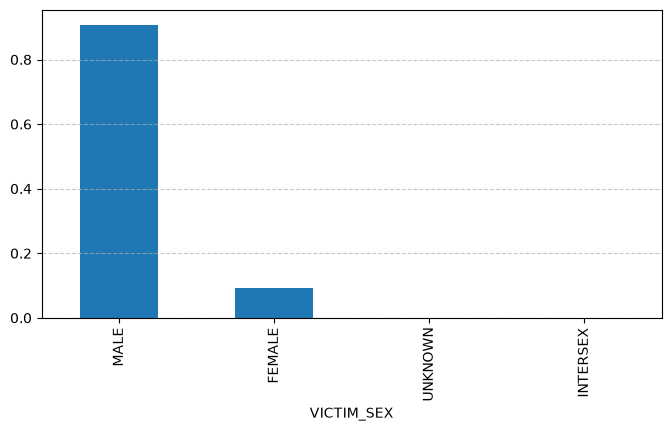

In [25]:
plt.figure(figsize=(8,4))
victim_sex.plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [26]:
victim_race = df_victims["VICTIM_RACE"].value_counts(normalize=True)
display(victim_race)

VICTIM_RACE
BLACK                             0.723220
WHITE HISPANIC                    0.141365
BLACK HISPANIC                    0.094013
WHITE                             0.023970
ASIAN / PACIFIC ISLANDER          0.014804
UNKNOWN                           0.002179
AMERICAN INDIAN/ALASKAN NATIVE    0.000450
Name: proportion, dtype: float64

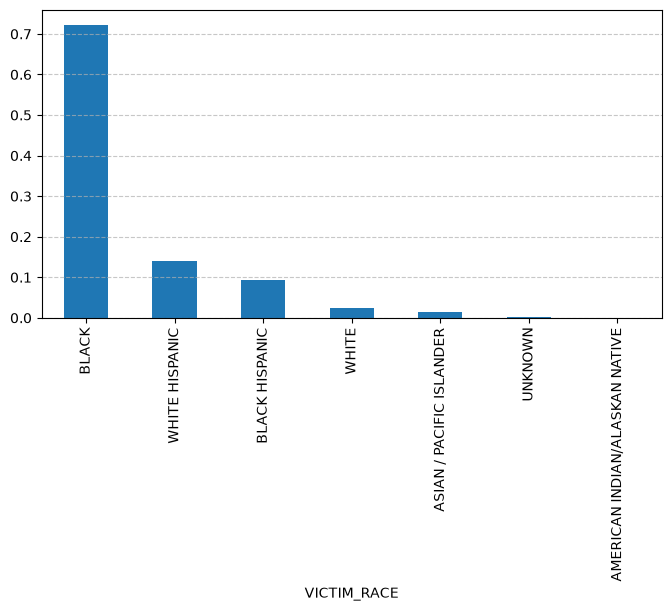

In [27]:
plt.figure(figsize=(8,4))
victim_race.plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [28]:
#how many shootings resulted in death
victim_died = df_victims["STAT_MURDER_FLG"].value_counts(normalize=True)
display(victim_died)


STAT_MURDER_FLG
N    0.833662
Y    0.166338
Name: proportion, dtype: float64

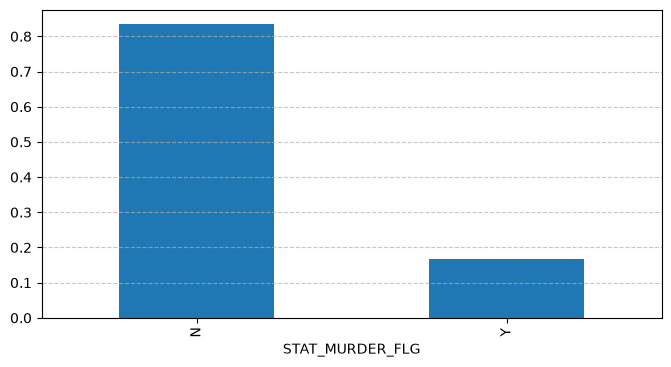

In [29]:
plt.figure(figsize=(8,4))
victim_died.plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.7)

- Must note that these only correspond to recorded shootings. 

## Are Consecutive Shootings Spatially Clustered?

In [37]:
#DBSCAN
#There is one row with missing X_COORD_CD and Y_COORD_CD - removing them
#Looking at shootings in 2024 and will compare with 2025 
df_dbscan = df_shootings[(df_shootings['X_COORD_CD'].notna()) & 
    (df_shootings['Y_COORD_CD'].notna()) &
    (df_shootings['datetime'].between("2024-01-01 00:00:00","2024-12-31 23:59:59"))
    ]


X = df_dbscan[['X_COORD_CD', 'Y_COORD_CD']]
#cluster radius of 500ft.
db = DBSCAN(eps=600, min_samples=10)

# Fit model and assign cluster labels back to the DataFrame
df_dbscan['Cluster_2024'] = db.fit_predict(X)

df_dbscan


,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,Cluster_2024
731,289881882,BROOKLYN,OUTSIDE,77,0.0,STREET,1000320.0,183659.0,40.670772,-73.942071,2024-07-10 21:30:00,Wednesday,Night,-1
903,299462478,QUEENS,INSIDE,109,0.0,DWELLING,1023909.0,224993.0,40.784149,-73.856792,2024-10-24 10:30:00,Thursday,Day,-1
1264,280768895,BRONX,OUTSIDE,48,0.0,STREET,1014054.0,246246.0,40.842522,-73.892284,2024-01-18 21:00:00,Thursday,Night,-1
1268,289881880,BROOKLYN,OUTSIDE,75,0.0,STREET,1013000.0,183339.0,40.669861,-73.896363,2024-07-10 03:59:00,Wednesday,Night,-1
2066,289889954,BROOKLYN,OUTSIDE,90,0.0,STREET,993507.0,196902.0,40.707131,-73.966613,2024-07-10 22:30:00,Wednesday,Night,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24065,296909032,STATEN ISLAND,OUTSIDE,120,0.0,STREET,959841.0,172627.0,40.640472,-74.087953,2024-11-21 16:40:00,Thursday,Day,-1
24066,297030186,BRONX,OUTSIDE,44,0.0,STREET,1006490.0,244533.0,40.837842,-73.919628,2024-11-24 05:50:00,Sunday,Night,0
24067,298301433,MANHATTAN,OUTSIDE,34,0.0,STREET,1004175.0,253200.0,40.861636,-73.927968,2024-12-20 19:40:00,Friday,Night,-1
24068,298515632,BRONX,INSIDE,52,0.0,OTHER,1017782.0,260028.0,40.880336,-73.878742,2024-12-26 18:39:00,Thursday,Night,-1


In [38]:
print(f"Cluster values for 2024: {df_dbscan["Cluster_2024"].value_counts()}")

Cluster values for 2024: Cluster_2024
-1    868
 1     15
 0     11
 2     10
Name: count, dtype: int64


In [39]:
cluster_1 = df_dbscan[df_dbscan['Cluster_2024']==1]

display(cluster_1[['BORO']].value_counts())

BORO 
BRONX    15
Name: count, dtype: int64

In [42]:
#DBSCAN
#There is one row with missing X_COORD_CD and Y_COORD_CD - removing them
#Looking at shootings in 2025 
df_dbscan = df_shootings[(df_shootings['X_COORD_CD'].notna()) & 
    (df_shootings['Y_COORD_CD'].notna()) &
    (df_shootings['datetime'].between("2025-01-01 00:00:00","2025-12-31 23:59:59"))
    ]


X = df_dbscan[['X_COORD_CD', 'Y_COORD_CD']]
#cluster radius of 500ft.
db = DBSCAN(eps=600, min_samples=7)

# Fit model and assign cluster labels back to the DataFrame
df_dbscan['Cluster_2025'] = db.fit_predict(X)

df_dbscan


,INCIDENT_KEY,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,datetime,day_of_week,day_or_night,Cluster_2025
7,300261481,QUEENS,OUTSIDE,114,0.0,HOUSING,1002916.0,221441.0,40.774469,-73.932608,2025-01-29 13:30:00,Wednesday,Day,-1
189,301321141,STATEN ISLAND,OUTSIDE,120,0.0,STREET,955760.0,164018.0,40.616830,-74.102621,2025-02-14 22:00:00,Friday,Night,-1
193,300341223,BROOKLYN,OUTSIDE,79,0.0,STREET,995261.0,191567.0,40.692485,-73.960295,2025-01-31 11:55:00,Friday,Day,-1
368,300131386,MANHATTAN,OUTSIDE,25,2.0,HOUSING,1001768.0,234797.0,40.811130,-73.936718,2025-01-27 23:15:00,Monday,Night,-1
374,300412113,QUEENS,OUTSIDE,104,0.0,STREET,1008052.0,197914.0,40.709881,-73.914148,2025-02-01 05:05:00,Saturday,Night,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24107,315805497,BRONX,OUTSIDE,43,0.0,STREET,1017854.0,240245.0,40.826037,-73.878581,2025-11-09 13:34:00,Sunday,Day,-1
24108,316246117,BROOKLYN,INSIDE,73,0.0,DWELLING,1009240.0,177953.0,40.655090,-73.909937,2025-11-17 07:45:00,Monday,Day,-1
24109,317233070,BRONX,OUTSIDE,47,0.0,STREET,1023852.0,265208.0,40.894528,-73.856761,2025-12-08 14:13:00,Monday,Day,-1
24110,317233069,QUEENS,OUTSIDE,114,0.0,STREET,1010918.0,217722.0,40.764241,-73.903732,2025-12-08 03:05:00,Monday,Night,-1


In [43]:
print(f"Cluster values for 2025: {df_dbscan["Cluster_2025"].value_counts()}")

Cluster values for 2025: Cluster_2025
-1    681
 0      7
Name: count, dtype: int64
